In [1]:
import pandas
import numpy
pandas.set_option("display.max_rows", None) 
pandas.set_option("display.max_columns", None)

#Loading the csv dataset "major-tech-stock-2019-2024.csv"
dataset = pandas.read_csv("./datasets/major-tech-stock-2019-2024.csv", header=0, index_col=0)

#Inspecting this dataset
print(dataset.head(), "\n")
print(dataset.tail(), "\n")
print(dataset.info(), "\n")
print(dataset.describe(), "\n")

                 Open       High        Low      Close  Adj Close     Volume  \
Date                                                                           
2019-01-02  38.722500  39.712502  38.557499  39.480000  37.793785  148158800   
2019-01-03  35.994999  36.430000  35.500000  35.547501  34.029243  365248800   
2019-01-04  36.132500  37.137501  35.950001  37.064999  35.481926  234428400   
2019-01-07  37.174999  37.207500  36.474998  36.982498  35.402950  219111200   
2019-01-08  37.389999  37.955002  37.130001  37.687500  36.077847  164101200   

           Ticker  
Date               
2019-01-02   AAPL  
2019-01-03   AAPL  
2019-01-04   AAPL  
2019-01-07   AAPL  
2019-01-08   AAPL   

                  Open        High         Low       Close   Adj Close  \
Date                                                                     
2023-12-22  256.760010  258.220001  251.369995  252.539993  252.539993   
2023-12-26  254.490005  257.970001  252.910004  256.609985  256.609985   
2

In [2]:
from sklearn.preprocessing import OrdinalEncoder

#Data Preprocessing: Ticker has even distribution across the 5 companies, so no sampling resolution is needed here.
print(dataset["Ticker"].value_counts(), "\n")

#Data Preprocessing: Ticker is a string column. It need to be encoded into numeric data using OrdinalEncoder
ordEnc = OrdinalEncoder(categories="auto")
dataset["Ticker"] = ordEnc.fit_transform(dataset[ ["Ticker"] ])

print(dataset["Ticker"].value_counts())

Ticker
AAPL     1258
MSFT     1258
AMZN     1258
GOOGL    1258
TSLA     1258
Name: count, dtype: int64 

Ticker
0.0    1258
3.0    1258
1.0    1258
2.0    1258
4.0    1258
Name: count, dtype: int64


In [3]:
#Since this dataset has 5 different tickers (AAPL, MSFT, AMZN, GOOGL, TSLA), we need to group the generated features per ticker

#Feature Generation: MA_7 (7 Day Moving Average)
dataset["MA_7"] = (dataset.groupby("Ticker")["Adj Close"].transform(lambda x: x.rolling(window=7).mean()))

#Feature Generation: MA_30 (30 day moving average)
dataset["MA_30"] = (dataset.groupby("Ticker")["Adj Close"].transform(lambda x: x.rolling(window=30).mean()))

#Feature Generation: Daily_Return (% return from open to close)
dataset["Daily_Return"] = (dataset["Close"] - dataset["Open"]) / dataset["Open"]

#Feature Generation: Momentum (how fast the price changes over 7 days)
dataset["Momentum_7d"] = (dataset.groupby("Ticker")["Adj Close"].transform(lambda x: x.pct_change(periods=7) * 100))

#Feature Generation: Volatility_7d (how much does the price fluctuate)
dataset["Volatility_7d"] = (dataset.groupby("Ticker")["Adj Close"].transform(lambda x: x.pct_change().rolling(7).std() * (252 ** 0.5)))        

def rsi(series, period=14):                                                             
    delta = series.diff()                                                               
    gain = delta.clip(lower=0).rolling(period).mean()                                   
    loss = -delta.clip(upper=0).rolling(period).mean()                                  
    return 100 - (100 / (1 + gain / loss))                                              

#Feature Generation: RSI_14 (range (0-100): >70 = overbought, <30 = oversold)                                                                     
dataset["RSI_14"] = (dataset.groupby("Ticker")["Adj Close"].transform(rsi))

#Viewing our newly generated features
print(dataset.info(), "\n")

<class 'pandas.DataFrame'>
Index: 6290 entries, 2019-01-02 to 2023-12-29
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Open           6290 non-null   float64
 1   High           6290 non-null   float64
 2   Low            6290 non-null   float64
 3   Close          6290 non-null   float64
 4   Adj Close      6290 non-null   float64
 5   Volume         6290 non-null   int64  
 6   Ticker         6290 non-null   float64
 7   MA_7           6260 non-null   float64
 8   MA_30          6145 non-null   float64
 9   Daily_Return   6290 non-null   float64
 10  Momentum_7d    6255 non-null   float64
 11  Volatility_7d  6255 non-null   float64
 12  RSI_14         6220 non-null   float64
dtypes: float64(12), int64(1)
memory usage: 817.0+ KB
None 



In [4]:
#Data Preprocessing: Rolling/window-absed features (MA_7, MA_30, Momentum_7d, Volatility_7d, RSI_14) produce NaN
#for the first (window_size - 1) rows per ticker. These rows will be dropped

#I'm not imputing NaNs here because they will be misleading values. At most we are losing 29 rows per ticker

dataset.dropna(inplace=True)
print(dataset.info(), "\n")

<class 'pandas.DataFrame'>
Index: 6145 entries, 2019-02-13 to 2023-12-29
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Open           6145 non-null   float64
 1   High           6145 non-null   float64
 2   Low            6145 non-null   float64
 3   Close          6145 non-null   float64
 4   Adj Close      6145 non-null   float64
 5   Volume         6145 non-null   int64  
 6   Ticker         6145 non-null   float64
 7   MA_7           6145 non-null   float64
 8   MA_30          6145 non-null   float64
 9   Daily_Return   6145 non-null   float64
 10  Momentum_7d    6145 non-null   float64
 11  Volatility_7d  6145 non-null   float64
 12  RSI_14         6145 non-null   float64
dtypes: float64(12), int64(1)
memory usage: 672.1+ KB
None 



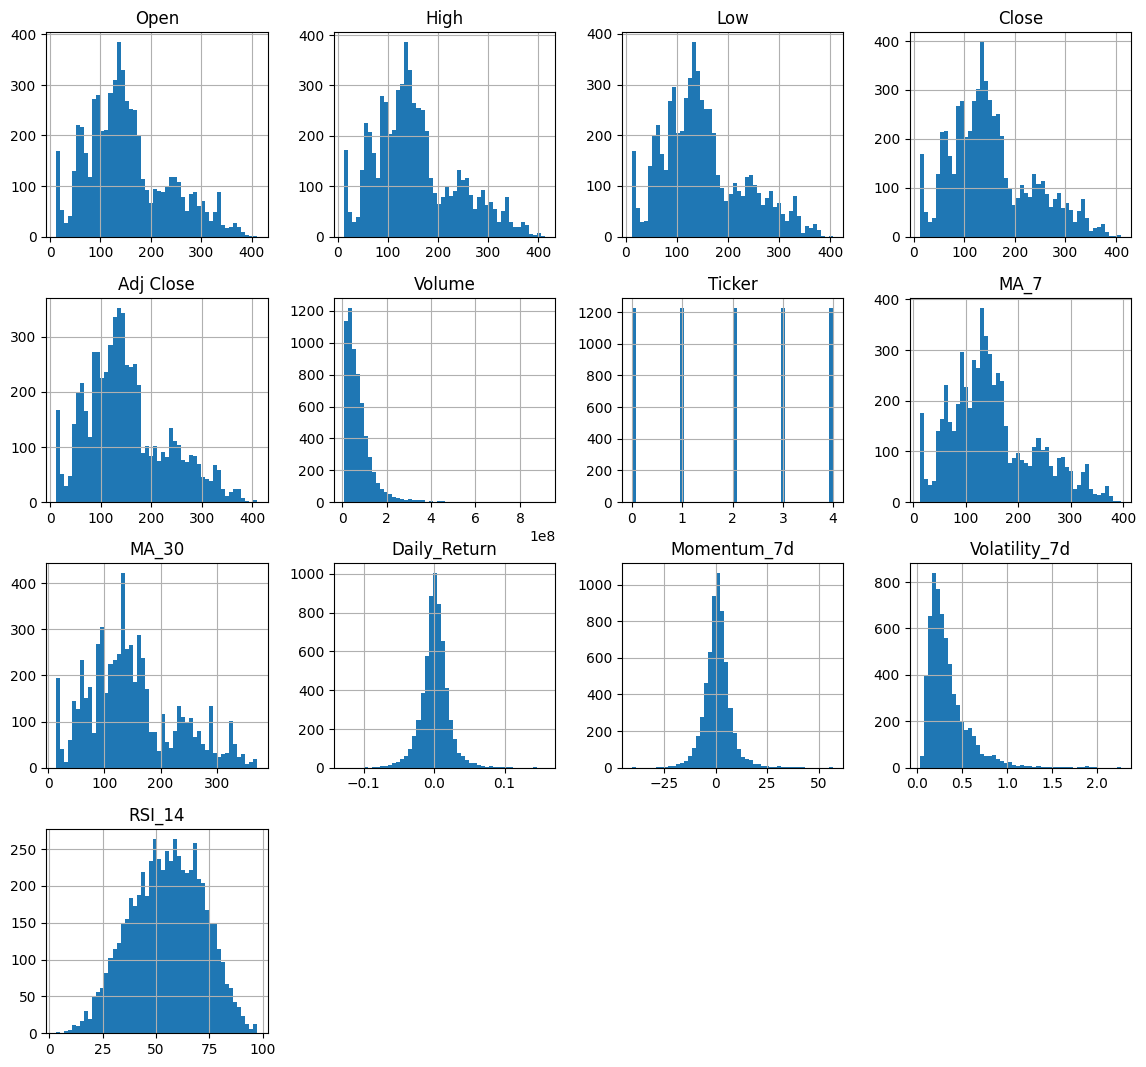

In [ ]:
import matplotlib.pyplot as plt

dataset.hist(bins=50, figsize=(14, 13))
plt.show()

In [6]:
#Feature Identification: choosing "Adj Close" as the target feature instead of "Close" because it corrects artificial price jumps on split dates

#The "Adj Close" feature gets shifted one day back, because this is a forecasting task. 
#We want day n to predict day n + 1's adj close.
dataset["Target"] = (                                                                                                               
    dataset.groupby("Ticker")["Adj Close"]
    .transform(lambda x: x.shift(-1))  # next day's price
)                                                                                                                                   
dataset.dropna(inplace=True)  # drops last row per ticker (no next day)
                                                                                                                                      
trgt_y = dataset[["Target"]]
feats_X = dataset.drop(columns=["Target", "Adj Close", "Close"])  

print(trgt_y.shape, "\n")
print(feats_X.shape, "\n")

(6140, 1) 

(6140, 11) 



In [9]:
from sklearn.feature_selection import SelectKBest

for t in range(trgt_y.shape[1]):
    print(t)

0
